In [351]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [352]:
file = uproot.open("build/yz.root")

print(file.keys()) 
tree = file["yz"]
df = tree.arrays(library="pd")

['yz;1']


### STEP 1
Plottare tutte e quantità del file

In [353]:
custom_ranges = {
    'radius': None,
    'nbHits': None,
    'nbScoredHits': None,
    'y': None,
    'z': None,
    'Einc': (-0.02, 0.02)
}

cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc']

units = {
    'radius': ' [nm]',
    'nbHits': '',
    'nbScoredHits': '',
    'y': ' [keV/um]',
    'z': ' [Gy]',
    'Einc': ' [MeV]'
} # Controlla se sto facendo bene...!

count = len(df)
# Senza [1:], includi TUTTI gli indici trovati
counts = df['nbScoredHits'].value_counts().sort_index()

n_zeros = (df['nbScoredHits'] == 0).sum()
print(f"Number of events with nbEdep = 0: {n_zeros}")

for i, count in counts.items():
    print(f"Number of events with nbEdep = {int(i)}: {int(count)}")

# Somma totale di tutto quello che hai trovato
print(f"Total of number of Event = {counts.sum()}")

Number of events with nbEdep = 0: 0
Number of events with nbEdep = 1: 1594
Number of events with nbEdep = 2: 1109
Number of events with nbEdep = 3: 1202
Number of events with nbEdep = 4: 1318
Number of events with nbEdep = 5: 1215
Number of events with nbEdep = 6: 1203
Number of events with nbEdep = 7: 1121
Number of events with nbEdep = 8: 1088
Number of events with nbEdep = 9: 1040
Number of events with nbEdep = 10: 1044
Number of events with nbEdep = 11: 1192
Number of events with nbEdep = 12: 962
Number of events with nbEdep = 13: 804
Number of events with nbEdep = 14: 687
Number of events with nbEdep = 15: 676
Number of events with nbEdep = 16: 664
Number of events with nbEdep = 17: 580
Number of events with nbEdep = 18: 530
Number of events with nbEdep = 19: 451
Number of events with nbEdep = 20: 430
Number of events with nbEdep = 21: 375
Number of events with nbEdep = 22: 366
Number of events with nbEdep = 23: 325
Number of events with nbEdep = 24: 305
Number of events with nbEd

 Istogramma radius ha un range impostato a: None
 Istogramma nbHits ha un range impostato a: None
 Istogramma nbScoredHits ha un range impostato a: None
 Istogramma y ha un range impostato a: None
 Istogramma z ha un range impostato a: None
 Istogramma Einc ha un range impostato a: (-0.02, 0.02)


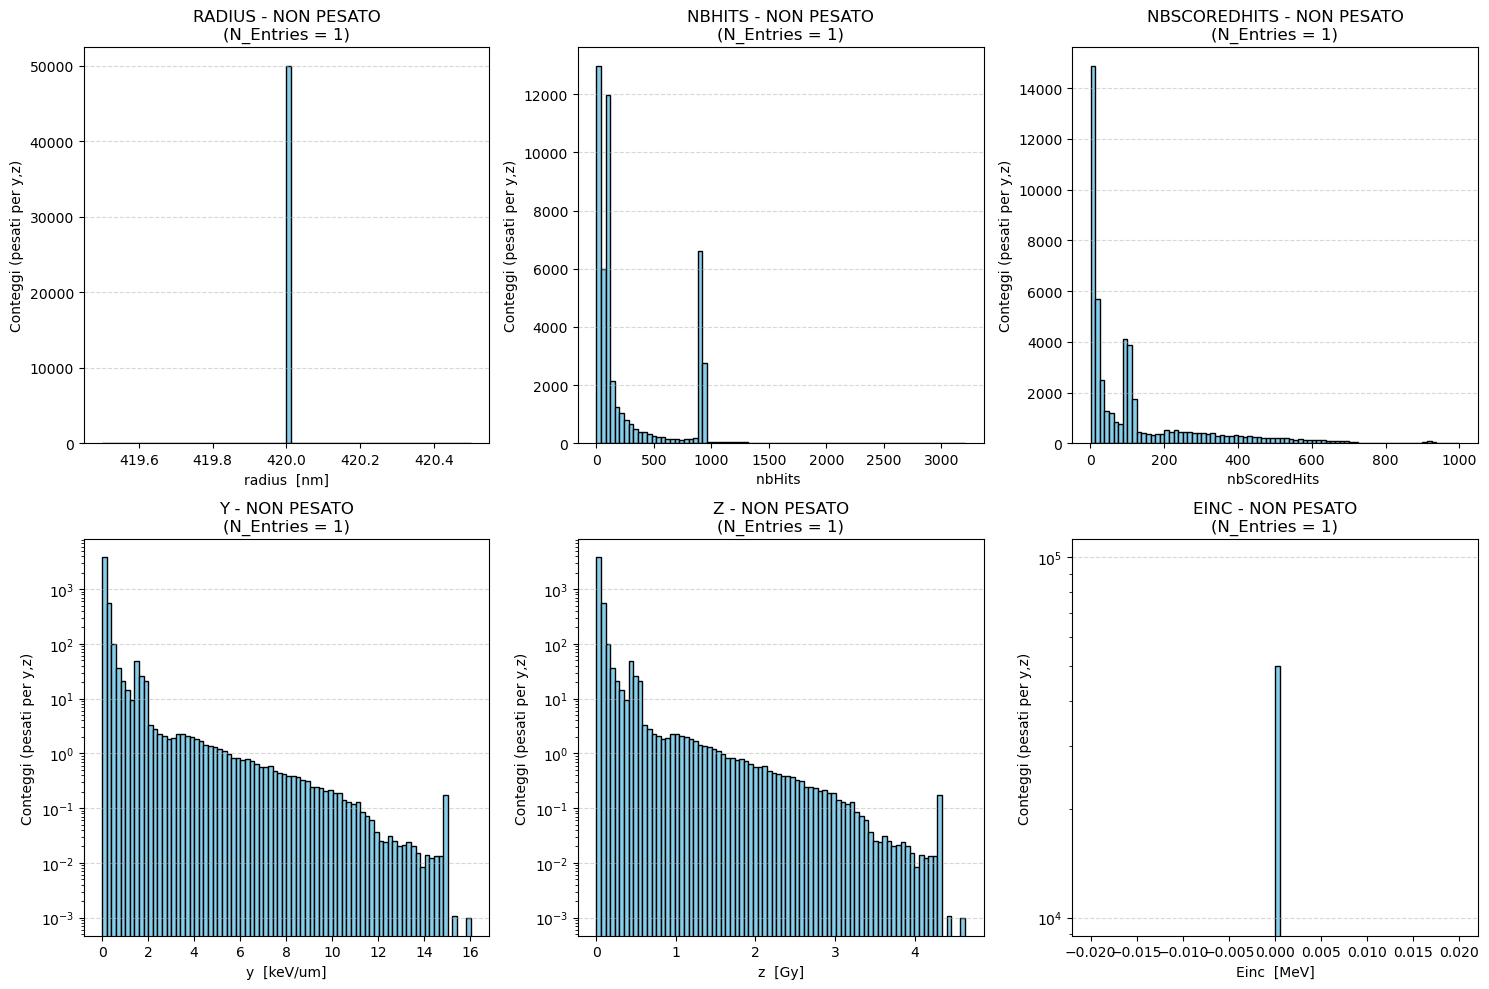

In [354]:
import matplotlib.pyplot as plt
import numpy as np

# 1. CALCOLO PESI (Una sola volta)
# Se nbScoredHits è > 0, il peso è 1/nbScoredHits, altrimenti è 0
df['weight'] = 1.0 / df['nbScoredHits']

# 2. DEFINIZIONE DELLE COLONNE E RANGE (Puoi personalizzare i range qui)
cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc']

# 3. PLOTTING
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    current_range = custom_ranges.get(col)
    print(f" Istogramma {col} ha un range impostato a: {current_range}")
    # Applichiamo il peso SOLO se la colonna è 'y' o 'z'
    current_weights = df['weight'] if col in ['y', 'z'] else None
    
    # Decidiamo la scala logaritmica (opzionale, basato sui tuoi dati)
    is_log = col in ['y', 'z', 'Einc']
    
    # Plot dell'istogramma
    axes[i].hist(df[col], bins=80, range=custom_ranges.get(col), 
                 color='skyblue', edgecolor='black', log=is_log, 
                 weights=current_weights)
    
    axes[i].set_title(f'{col.upper()} - NON PESATO\n(N_Entries = {count})')
    axes[i].set_xlabel(f'{col} {units.get(col, "")}')
    axes[i].set_ylabel('Conteggi (pesati per y,z)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

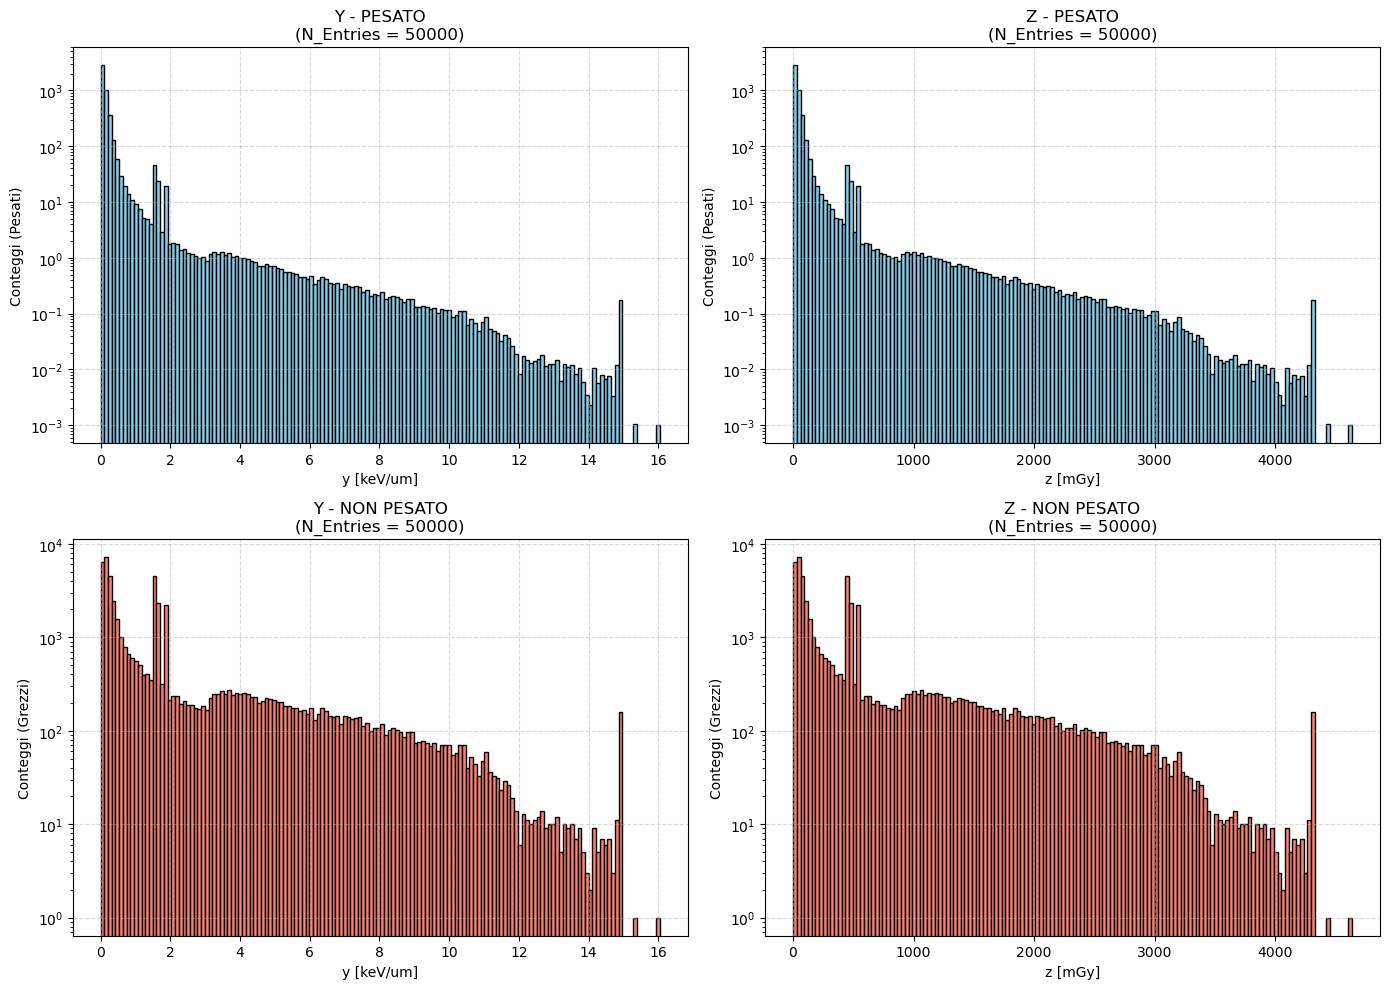

In [355]:
import matplotlib.pyplot as plt
import numpy as np

# Fattori di conversione
scales = {'y': 1.0, 'z': 1000.0}
units_label = {'y': 'keV/um', 'z': 'mGy'}

# Creiamo la figura
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Definiamo le colonne
cols = ['y', 'z']

for i, col in enumerate(cols):
    data = df[col] * scales[col]
    
    # Calcolo conteggi
    # Per il non pesato: numero puro di eventi
    count = len(df)
    
    # 1. GRAFICO PESATO (Corretto)
    axes[0, i].hist(data, bins=150, range=None, weights=df['weight'], 
                    color='skyblue', edgecolor='black', log=True)
    axes[0, i].set_title(f'{col.upper()} - PESATO\n(N_Entries = {count:.0f})')
    axes[0, i].set_ylabel('Conteggi (Pesati)')
    axes[0, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[0, i].grid(linestyle='--', alpha=0.5)

    # 2. GRAFICO NON PESATO (Grezzo)
    axes[1, i].hist(data, bins=150, range=None, weights=None, 
                    color='salmon', edgecolor='black', log=True)
    axes[1, i].set_title(f'{col.upper()} - NON PESATO\n(N_Entries = {count})')
    axes[1, i].set_ylabel('Conteggi (Grezzi)')
    axes[1, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[1, i].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Step 2
Entriamo nello specifico della lineal energy, y, e della specific energy, z.

Calcoliamo $y_F$ e $z_F$.

In [356]:
# Filtriamo i dati per evitare divisioni per zero o valori non fisici
y_data = df[df['y'] > 0]['y']
z_data = df[df['z'] > 0]['z']

### Step 3
Intera pipeline dalle quantità microdosimetriche a MKM e LQ model.

In [357]:
R_d = 0.420       # Raggio del dominio sensibile in micrometri (420 nm -> 0.420 um)
R_n = 4.0         # Raggio del nucleo cellulare in micrometri (4.0 um)
y0 = 150.0        # Parametro di saturazione MKM [keV/um]
alpha_0 = 0.147   # Radiosensibilità lineare di riferimento [Gy^-1]
beta_cell = 0.02  # Coefficiente quadratico [Gy^-2]

# Costante di conversione microdosimetrica sferica
k_conv = 0.12015 / R_d 

# Ora il rapporto volumi sarà una frazione piccolissima (circa 0.001157)
rapporto_volumi = (R_d / R_n)**3 

In [358]:
# Calcolo analitico di y_F (Mean) e y_D (Dose-mean) per la diagnostica
y_f_mean = y_data.mean()
y_d_dose_mean = (y_data**2).sum() / y_data.sum()

# Calcolo di y* (energia lineare media pesata in dose satura per il MKM)
y_numerator = np.sum((y0**2) * (1 - np.exp(-(y_data**2) / (y0**2))))
y_denominator = np.sum(y_data)
y_star = y_numerator / y_denominator

# Calcolo dell'Alpha cellulare effettivo secondo il modello MKM
alpha_cell = alpha_0 + (beta_cell * k_conv * y_star)

print("\n--- DIAGNOSTICA PARAMETRI FISICI ---")
print(f"y_F (Frequency-mean): {y_f_mean:.4f} keV/um")
print(f"y_D (Dose-mean):      {y_d_dose_mean:.4f} keV/um")
print(f"y* (Satura MKM):      {y_star:.4f} keV/um")
print(f"Alpha Cell (MKM):     {alpha_cell:.4f} Gy^-1")
print(f"Dose media per singolo hit (z_F): {z_data.mean():.4f} Gy")
print("------------------------------------\n")


--- DIAGNOSTICA PARAMETRI FISICI ---
y_F (Frequency-mean): 2.0367 keV/um
y_D (Dose-mean):      5.7073 keV/um
y* (Satura MKM):      5.6975 keV/um
Alpha Cell (MKM):     0.1796 Gy^-1
Dose media per singolo hit (z_F): 0.5888 Gy
------------------------------------



Decadimenti (N) |   Dose Nucleo [Gy] |   Sopravvivenza |        RBE
----------------------------------------------------------------------
            100 |             0.0682 |      9.8774e-01 |       1.22
            301 |             0.2052 |      9.6301e-01 |       1.21
            502 |             0.3422 |      9.3819e-01 |       1.20
            703 |             0.4792 |      9.1333e-01 |       1.19
            904 |             0.6162 |      8.8846e-01 |       1.19
           1105 |             0.7532 |      8.6361e-01 |       1.18
           1306 |             0.8903 |      8.3884e-01 |       1.18
           1507 |             1.0273 |      8.1416e-01 |       1.17
           1708 |             1.1643 |      7.8961e-01 |       1.17
           1909 |             1.3013 |      7.6523e-01 |       1.16
           2110 |             1.4383 |      7.4104e-01 |       1.16
           2311 |             1.5753 |      7.1708e-01 |       1.15
           2512 |             1.7124 |      6

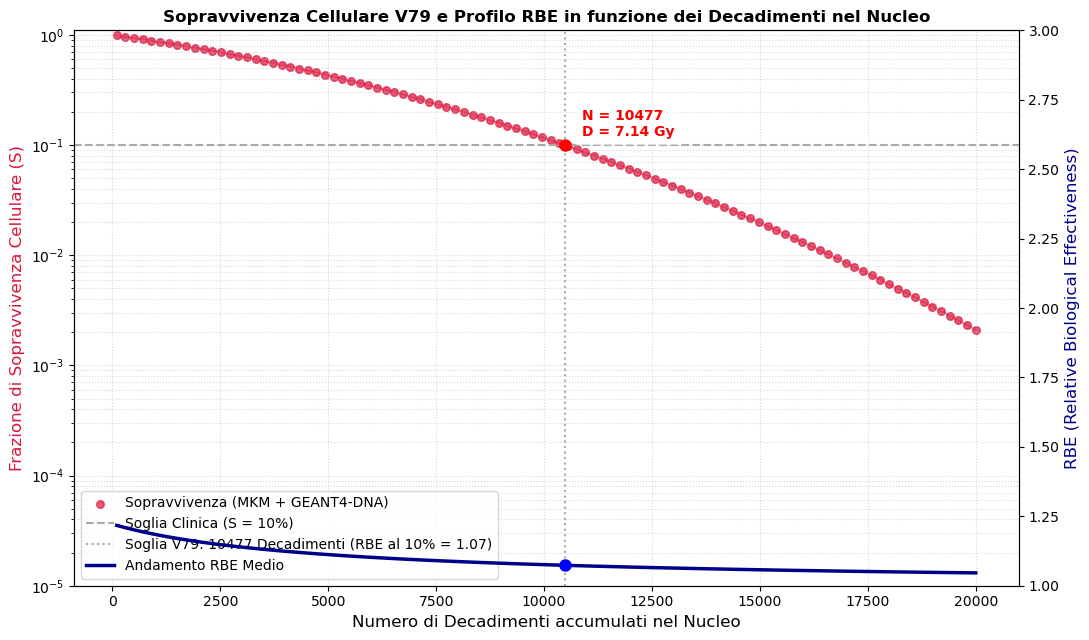

Calcolo completato con successo!
Decadimenti necessari per inattivazione al 10%: 10477


In [359]:
casi_decadimenti = np.linspace(100, 20000, 100) 

risultati_sopravvivenza = []
dosi_medie_nucleo = []
rbe_medi_analitici = []

# Valore medio della dose depositata nel dominio per singolo evento primario
z_medio_evento = z_data.mean() 

print(f"{'Decadimenti (N)':>15} | {'Dose Nucleo [Gy]':>18} | {'Sopravvivenza':>15} | {'RBE':>10}")
print("-" * 70)

for N in casi_decadimenti:
    # Calcolo lineare della dose macroscopica del nucleo cellulare (D) 
    D_nucleo = N * (z_medio_evento * rapporto_volumi)
    
    # Calcolo della sopravvivenza macroscopica con alpha_cell corretto
    S = np.exp(-alpha_cell * D_nucleo - beta_cell * (D_nucleo**2))
    
    # Calcolo dell'RBE analitico lungo la curva
    if D_nucleo > 0:
        rbe_punto = (np.sqrt(alpha_0**2 + 4 * beta_cell * (alpha_cell * D_nucleo + beta_cell * (D_nucleo**2))) - alpha_0) / (2 * beta_cell * D_nucleo)
    else:
        rbe_punto = alpha_cell / alpha_0
        
    risultati_sopravvivenza.append(S)
    dosi_medie_nucleo.append(D_nucleo)
    rbe_medi_analitici.append(rbe_punto)
    
    print(f"{int(N):15d} | {D_nucleo:18.4f} | {S:15.4e} | {rbe_punto:10.2f}")

# --- CALCOLO SOGLIE BIOLOGICHE ED INTERSEZIONI ---
log_S_rev = np.log(np.array(risultati_sopravvivenza)[::-1])
casi_rev = casi_decadimenti[::-1]
decadimenti_soglia = np.interp(np.log(0.10), log_S_rev, casi_rev)

# Calcolo RBE e Dose esatti al 10% di sopravvivenza
dosi_nucleo_array = np.array(dosi_medie_nucleo)
dose_soglia_sim = np.interp(np.log(0.10), log_S_rev, dosi_nucleo_array[::-1])
dose_soglia_ref = (-alpha_0 + np.sqrt(alpha_0**2 - 4 * beta_cell * np.log(0.10))) / (2 * beta_cell)
rbe_al_10 = dose_soglia_ref / dose_soglia_sim

rbe_medi_analitici = np.array(rbe_medi_analitici)
rbe_soglia_grafico = np.interp(decadimenti_soglia, casi_decadimenti, rbe_medi_analitici)

# ==============================================================================
# 5. GENERAZIONE GRAFICO AD ALTA RISOLUZIONE
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(11, 6.5))

# ASSE SINISTRO: Frazione di Sopravvivenza (S)
color_s = 'crimson'
ax1.scatter(casi_decadimenti, risultati_sopravvivenza, color=color_s, s=30, alpha=0.7, label='Sopravvivenza (MKM + GEANT4-DNA)')
ax1.plot(casi_decadimenti, risultati_sopravvivenza, color=color_s, linestyle='-', alpha=0.4, linewidth=1.5)
ax1.set_yscale('log')
ax1.set_ylim(1e-5, 1.1)  
ax1.set_xlabel("Numero di Decadimenti accumulati nel Nucleo", fontsize=12)
ax1.set_ylabel("Frazione di Sopravvivenza Cellulare (S)", color=color_s, fontsize=12)
ax1.grid(True, which="both", linestyle=":", alpha=0.5)

# ASSE DESTRO: Profilo dell'RBE
ax2 = ax1.twinx()
color_rbe = 'darkblue'
ax2.plot(casi_decadimenti, rbe_medi_analitici, color=color_rbe, linestyle='-', linewidth=2.5, label='Andamento RBE Medio')
ax2.set_ylabel("RBE (Relative Biological Effectiveness)", color=color_rbe, fontsize=12)
ax2.set_ylim(1.0, 3.0) 

# --- LINEE DI SOGLIA ---
line_soglia = ax1.axhline(y=0.10, color='darkgray', linestyle='--', linewidth=1.5, 
                         label='Soglia Clinica (S = 10%)')

line_vert = ax1.axvline(x=decadimenti_soglia, color='darkgray', linestyle=':', linewidth=1.5,
                        label=f'Soglia V79: {int(np.ceil(decadimenti_soglia))} Decadimenti (RBE al 10% = {rbe_al_10:.2f})')

# --- MARKER DI INTERSEZIONE GRAFICA ---
ax1.plot(decadimenti_soglia, 0.10, marker='o', color='red', markersize=8, zorder=5)
ax2.plot(decadimenti_soglia, rbe_soglia_grafico, marker='o', color='blue', markersize=8, zorder=5)

# Box di testo con i dati reali di lavoro vicino all'incrocio
ax1.text(decadimenti_soglia + 400, 0.12, f"N = {int(np.ceil(decadimenti_soglia))}\nD = {dose_soglia_sim:.2f} Gy", 
         fontsize=10, color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# UNIONE DELLE LEGENDE IN UN UNICO BOX
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='lower left')

plt.title("Sopravvivenza Cellulare V79 e Profilo RBE in funzione dei Decadimenti nel Nucleo", fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

print(f"Calcolo completato con successo!")
print(f"Decadimenti necessari per inattivazione al 10%: {int(np.ceil(decadimenti_soglia))}")

Qui vado solo a "migliorare" la visibilità del plot.

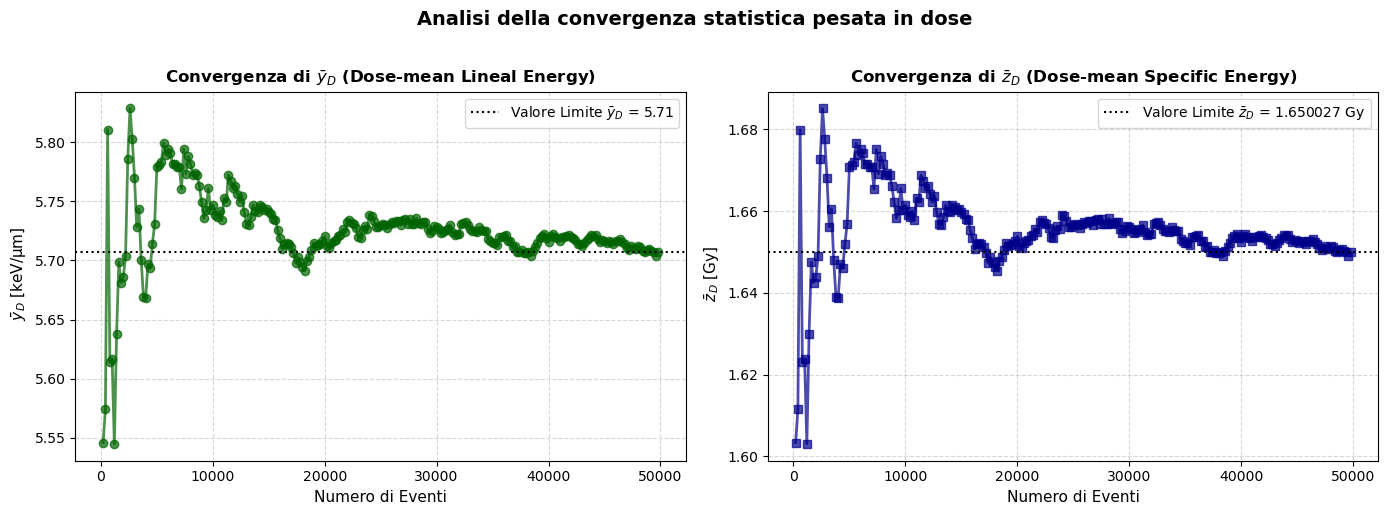

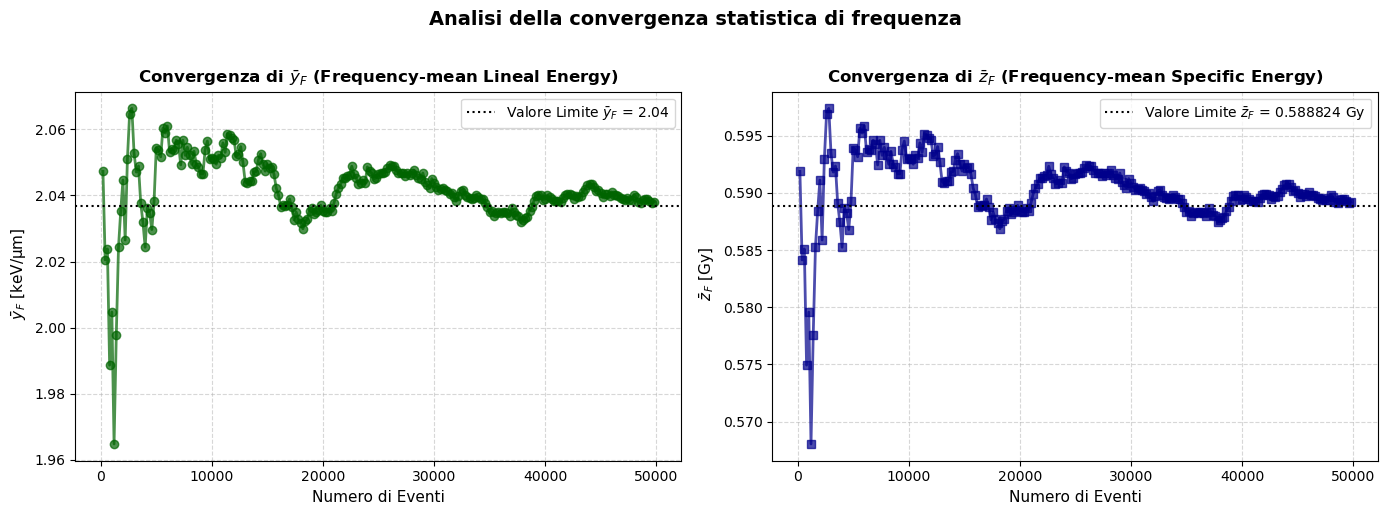

In [360]:
# ==============================================================================
# STUDIO DELLA CONVERGENZA STATISTICA DI y_D E z_D (PESATI IN DOSE)
# ==============================================================================
# Partiamo da un numero minimo di eventi (es. 'step') per evitare divisioni per zero all'inizio
step = 200
step_statistica = np.arange(step, len(y_data), step) 

y_f_cumulativi = []
z_f_cumulativi = []

y_d_cumulativi = []
z_d_cumulativi = []

# Calcoliamo i valori "di riferimento" (limiti) sull'intero dataset per le linee orizzontali
#y_f e z_f
ref_y_f = np.mean(y_data)
ref_z_f = np.mean(z_data)
#y_d e z_d
ref_y_d = np.sum(y_data**2) / np.sum(y_data)
ref_z_d = np.sum(z_data**2) / np.sum(z_data)

for n_eventi in step_statistica:
    # Estraiamo i sottogruppi
    y_sub = y_data[:n_eventi]
    z_sub = z_data[:n_eventi]
    
    # Calcolo della media pesata in dose (Dose-mean)
    # Formula: sum(x^2) / sum(x)
    y_f_cumulativi.append(np.mean(y_sub))
    z_f_cumulativi.append(np.mean(z_sub))
    y_d_cumulativi.append(np.sum(y_sub**2) / np.sum(y_sub))
    z_d_cumulativi.append(np.sum(z_sub**2) / np.sum(z_sub))

# Convertiamo in array
y_f_cumulativi = np.array(y_f_cumulativi)
z_f_cumulativi = np.array(z_f_cumulativi)

y_d_cumulativi = np.array(y_d_cumulativi)
z_d_cumulativi = np.array(z_d_cumulativi)

# --- GENERAZIONE DEL GRAFICO DI CONVERGENZA PESATA ---
fig, (ax_y, ax_z) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot per y_D
ax_y.plot(step_statistica, y_d_cumulativi, marker='o', color='darkgreen', linewidth=2, linestyle='-', alpha=0.7)
ax_y.axhline(y=ref_y_d, color='black', linestyle=':', label=f'Valore Limite $\\bar{{y}}_D$ = {ref_y_d:.2f}')
ax_y.set_xlabel("Numero di Eventi", fontsize=11)
ax_y.set_ylabel(r" $\bar{y}_D$ [keV/µm]", fontsize=11)
ax_y.set_title(r"Convergenza di $\bar{y}_D$ (Dose-mean Lineal Energy)", fontsize=12, fontweight='bold')
ax_y.grid(True, linestyle='--', alpha=0.5)
ax_y.legend()

# 2. Plot per z_D
ax_z.plot(step_statistica, z_d_cumulativi, marker='s', color='darkblue', linewidth=2, linestyle='-', alpha=0.7)
ax_z.axhline(y=ref_z_d, color='black', linestyle=':', label=f'Valore Limite $\\bar{{z}}_D$ = {ref_z_d:.6f} Gy')
ax_z.set_xlabel("Numero di Eventi", fontsize=11)
ax_z.set_ylabel(r" $\bar{z}_D$ [Gy]", fontsize=11)
ax_z.set_title(r"Convergenza di $\bar{z}_D$ (Dose-mean Specific Energy)", fontsize=12, fontweight='bold')
ax_z.grid(True, linestyle='--', alpha=0.5)
ax_z.legend()

plt.suptitle("Analisi della convergenza statistica pesata in dose", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- GENERAZIONE DEL GRAFICO DI CONVERGENZA NON PESATA ---
fig, (ax_y, ax_z) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot per y_F
ax_y.plot(step_statistica, y_f_cumulativi, marker='o', color='darkgreen', linewidth=2, linestyle='-', alpha=0.7)
ax_y.axhline(y=ref_y_f, color='black', linestyle=':', label=f'Valore Limite $\\bar{{y}}_F$ = {ref_y_f:.2f}')
ax_y.set_xlabel("Numero di Eventi", fontsize=11)
ax_y.set_ylabel(r" $\bar{y}_F$ [keV/µm]", fontsize=11)
ax_y.set_title(r"Convergenza di $\bar{y}_F$ (Frequency-mean Lineal Energy)", fontsize=12, fontweight='bold')
ax_y.grid(True, linestyle='--', alpha=0.5)
ax_y.legend()

# 2. Plot per z_F
ax_z.plot(step_statistica, z_f_cumulativi, marker='s', color='darkblue', linewidth=2, linestyle='-', alpha=0.7)
ax_z.axhline(y=ref_z_f, color='black', linestyle=':', label=f'Valore Limite $\\bar{{z}}_F$ = {ref_z_f:.6f} Gy')
ax_z.set_xlabel("Numero di Eventi", fontsize=11)
ax_z.set_ylabel(r" $\bar{z}_F$ [Gy]", fontsize=11)
ax_z.set_title(r"Convergenza di $\bar{z}_F$ (Frequency-mean Specific Energy)", fontsize=12, fontweight='bold')
ax_z.grid(True, linestyle='--', alpha=0.5)
ax_z.legend()

plt.suptitle("Analisi della convergenza statistica di frequenza", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
